# DESAFIO 09 - IRIS  
## Grupo 09  
- Felipe Estevo Freitas RA: 1990153
- Marcela Kawamoto RA: 2224453

---

## Ajustes feitos para a P2

Principais melhorias feitas:

- o notebook foi dividido em etapas;
- cada etapa tem uma explicação antes do código;
- a análise exploratória ficou mais organizada;
- a divisão treino, validação e teste foi mantida em 60%, 20% e 20%;
- a comparação dos modelos foi feita com validação cruzada;
- a escolha do modelo final agora segue o resultado das métricas;
- o modelo final é salvo para ser usado depois no Streamlit;
- os resultados finais devem ser os mesmos no notebook, relatório e aplicação.

O dataset utilizado é o **Iris**, carregado diretamente pela biblioteca `scikit-learn`.

# 1. Importação das bibliotecas

Nesta etapa, importamos as bibliotecas usadas no projeto.

O `pandas` e o `numpy` ajudam na organização dos dados.  
O `matplotlib` e o `seaborn` são usados para gerar gráficos.  
O `scikit-learn` fornece o dataset Iris, os modelos de classificação, a divisão dos dados, a validação cruzada e as métricas.  
O `joblib` será usado para salvar o modelo final.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os
import pickle

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA

from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

RANDOM_STATE = 42
sns.set_theme(style="whitegrid")

# 2. Carregamento dos dados

Aqui carregamos o dataset Iris diretamente do `scikit-learn`.

Esse dataset possui medidas de flores Iris e a espécie de cada flor.  
As espécies são:

- setosa;
- versicolor;
- virginica.

As variáveis de entrada são medidas da sépala e da pétala.

In [2]:
iris = load_iris(as_frame=True)

df = iris.frame.copy()

df["species"] = df["target"].map({
    0: "setosa",
    1: "versicolor",
    2: "virginica"
})

df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,species
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


# 3. Visualização inicial dos dados

Antes de criar os modelos, precisamos entender como o dataset está organizado.

Nesta parte, verificamos:

- quantidade de linhas e colunas;
- nomes das colunas;
- tipos de dados;
- primeiras linhas;
- estatísticas gerais.

In [3]:
print("Quantidade de linhas e colunas:", df.shape)
df.head()

Quantidade de linhas e colunas: (150, 6)


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,species
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   target             150 non-null    int64  
 5   species            150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB


In [5]:
df.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


# 4. Verificação de valores ausentes e duplicados

Aqui verificamos se existem valores faltantes ou linhas duplicadas.

Isso é importante porque problemas nos dados podem prejudicar o treinamento dos modelos.

In [6]:
print("Valores ausentes por coluna:")
display(df.isnull().sum())

print("Quantidade de linhas duplicadas:", df.duplicated().sum())

Valores ausentes por coluna:


sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
target               0
species              0
dtype: int64

Quantidade de linhas duplicadas: 1


# 5. Distribuição das classes

Agora analisamos a quantidade de exemplos em cada espécie.

Como o problema é de classificação, é importante verificar se as classes estão equilibradas.  
No Iris, as três espécies possuem a mesma quantidade de amostras.

In [7]:
df["species"].value_counts()

species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64

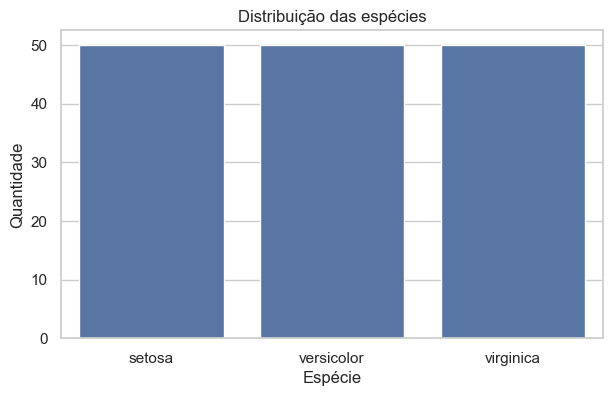

In [8]:
plt.figure(figsize=(7, 4))
sns.countplot(data=df, x="species")
plt.title("Distribuição das espécies")
plt.xlabel("Espécie")
plt.ylabel("Quantidade")
plt.show()

# 6. Distribuição das features

Nesta etapa, analisamos as medidas das flores.

Os histogramas ajudam a entender a distribuição de cada variável numérica.

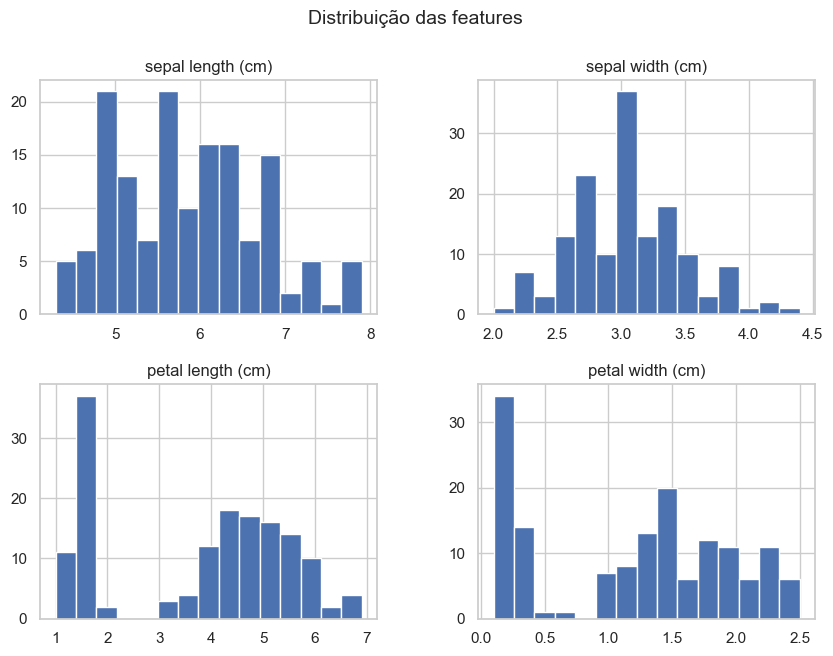

In [9]:
features = iris.feature_names

df[features].hist(figsize=(10, 7), bins=15)
plt.suptitle("Distribuição das features", fontsize=14)
plt.show()

# 7. Comparação das features por espécie

Os boxplots ajudam a comparar as medidas entre as espécies.

Essa análise ajuda a identificar quais variáveis separam melhor as flores.

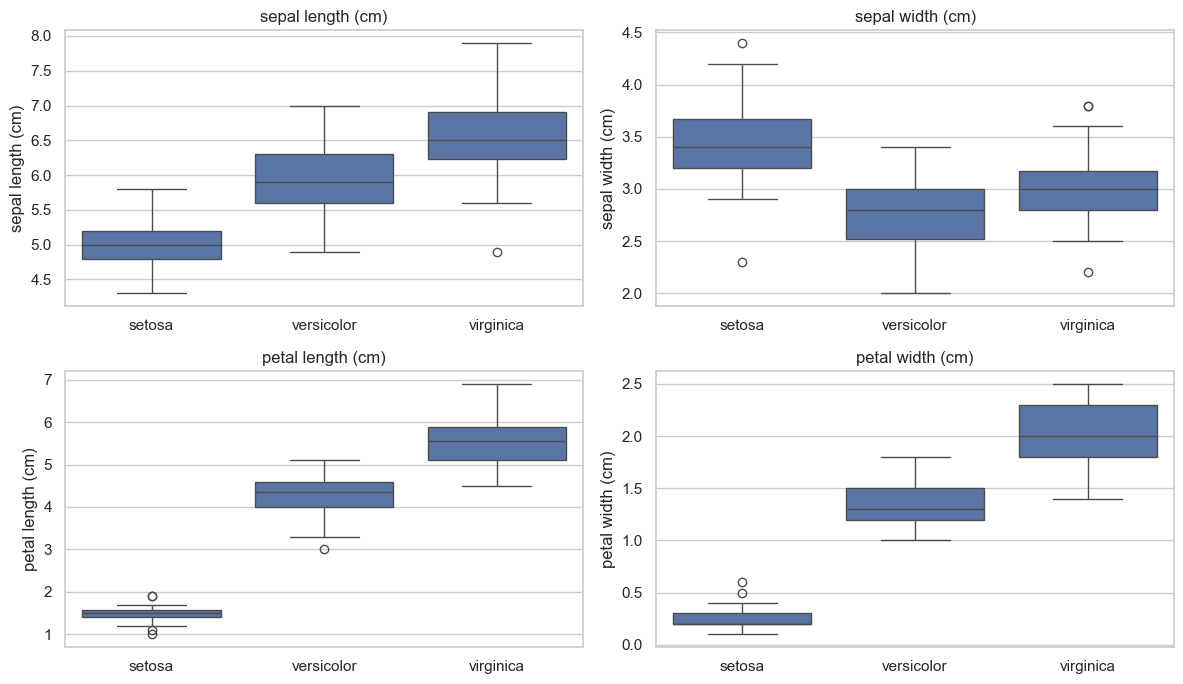

In [10]:
plt.figure(figsize=(12, 7))

for i, feature in enumerate(features, 1):
    plt.subplot(2, 2, i)
    sns.boxplot(data=df, x="species", y=feature)
    plt.title(feature)
    plt.xlabel("")

plt.tight_layout()
plt.show()

# 8. Pairplot das features

O pairplot mostra a relação entre as variáveis duas a duas.

Ele é muito útil no dataset Iris, porque mostra que a espécie **setosa** costuma ser bem separada das outras.  
Também é possível perceber que **versicolor** e **virginica** ficam mais próximas, principalmente em algumas medidas.

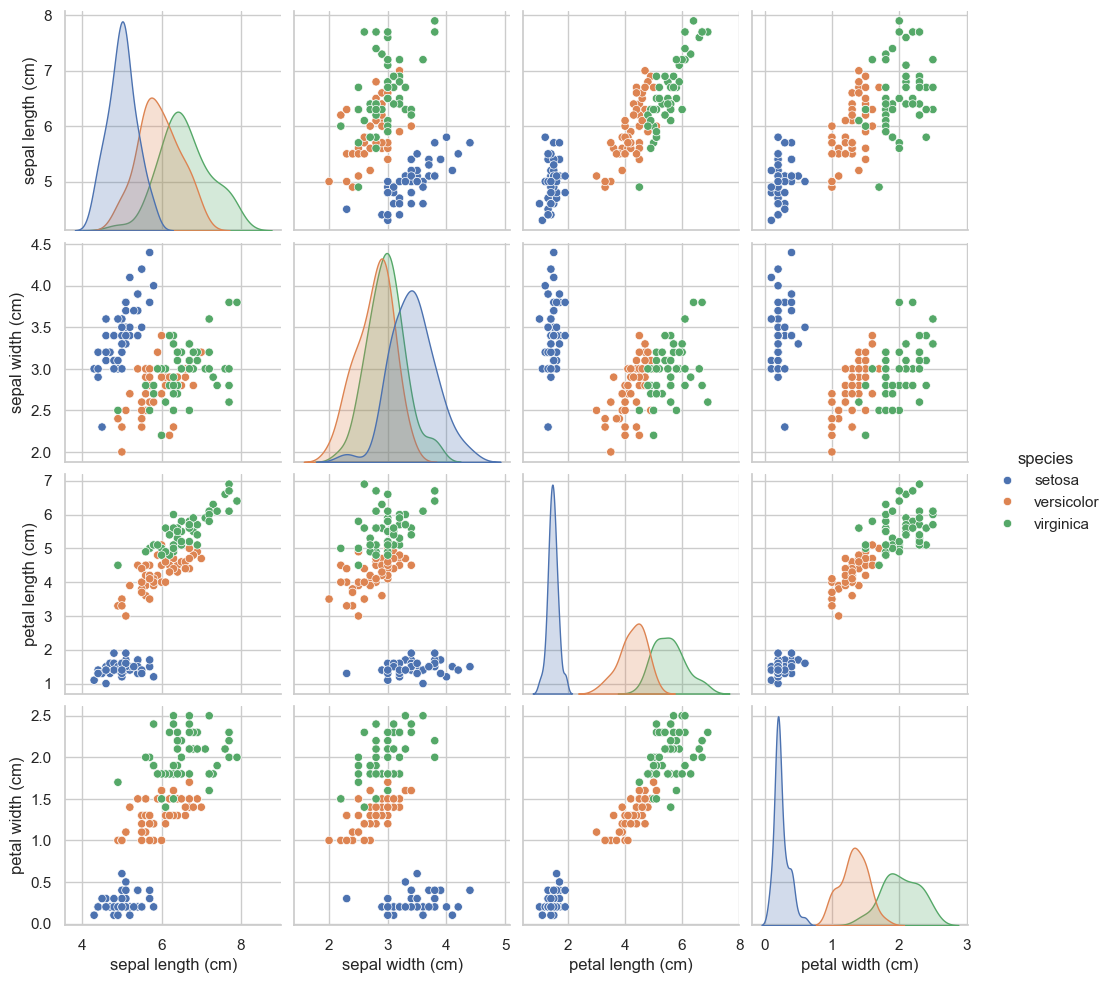

In [11]:
sns.pairplot(df, vars=features, hue="species")
plt.show()

# 9. Correlação entre as variáveis

A matriz de correlação mostra como as variáveis numéricas se relacionam.

No Iris, as medidas de pétala geralmente apresentam forte relação com a separação das espécies.

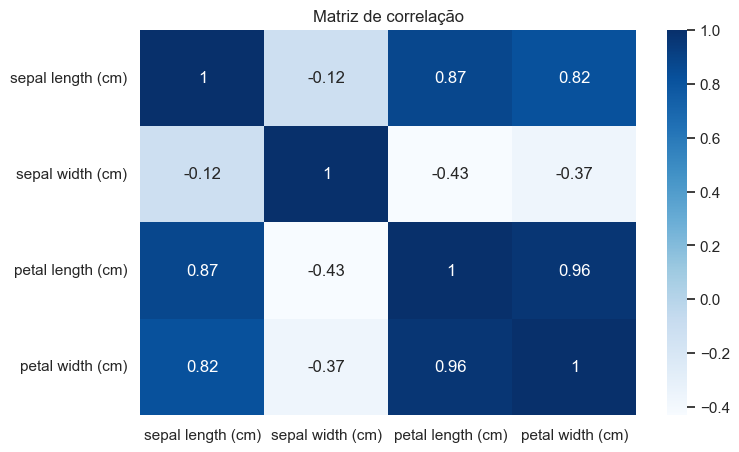

In [12]:
plt.figure(figsize=(8, 5))
sns.heatmap(df[features].corr(), annot=True, cmap="Blues")
plt.title("Matriz de correlação")
plt.show()

# 10. Separação entre X e y

Agora separamos os dados em:

- `X`: variáveis de entrada usadas pelo modelo;
- `y`: variável-alvo, que representa a espécie da flor.

A coluna `target` será usada como alvo numérico.  
A coluna `species` fica apenas para facilitar a leitura dos resultados.

In [13]:
X = df[features]
y = df["target"]

target_names = iris.target_names

print("Variáveis de entrada:")
display(X.head())

print("Classes:")
for i, name in enumerate(target_names):
    print(i, "=", name)

Variáveis de entrada:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


Classes:
0 = setosa
1 = versicolor
2 = virginica


# 11. Divisão em treino, validação e teste

A divisão segue o que foi pedido no desafio:

- 60% para treino;
- 20% para validação;
- 20% para teste.

Usamos `stratify` para manter a proporção das três espécies em cada conjunto.  
Também usamos `random_state` para garantir reprodutibilidade.

In [14]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.40,
    stratify=y,
    random_state=RANDOM_STATE
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=RANDOM_STATE
)

print("Treino:", X_train.shape)
print("Validação:", X_val.shape)
print("Teste:", X_test.shape)

Treino: (90, 4)
Validação: (30, 4)
Teste: (30, 4)


In [15]:
print("Distribuição no treino:")
print(y_train.value_counts().sort_index())

print("\nDistribuição na validação:")
print(y_val.value_counts().sort_index())

print("\nDistribuição no teste:")
print(y_test.value_counts().sort_index())

Distribuição no treino:
target
0    30
1    30
2    30
Name: count, dtype: int64

Distribuição na validação:
target
0    10
1    10
2    10
Name: count, dtype: int64

Distribuição no teste:
target
0    10
1    10
2    10
Name: count, dtype: int64


# 12. Normalização e criação dos modelos

A normalização é importante para modelos que dependem de distância ou escala, como KNN e Regressão Logística.

Para organizar melhor, usamos `Pipeline`.  
Assim, o modelo já recebe os dados normalizados automaticamente quando necessário.

Serão comparados três classificadores:

- KNN;
- Regressão Logística;
- Random Forest.

In [16]:
models = {
    "KNN": Pipeline([
        ("scaler", StandardScaler()),
        ("model", KNeighborsClassifier(n_neighbors=5))
    ]),

    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=500, random_state=RANDOM_STATE))
    ]),

    "Random Forest": Pipeline([
        ("model", RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE))
    ])
}

models

{'KNN': Pipeline(steps=[('scaler', StandardScaler()),
                 ('model', KNeighborsClassifier())]),
 'Logistic Regression': Pipeline(steps=[('scaler', StandardScaler()),
                 ('model', LogisticRegression(max_iter=500, random_state=42))]),
 'Random Forest': Pipeline(steps=[('model',
                  RandomForestClassifier(n_estimators=200, random_state=42))])}

# 13. Validação cruzada com StratifiedKFold

A validação cruzada permite avaliar os modelos de forma mais confiável.

Aqui usamos `StratifiedKFold` com 5 divisões.  
O termo `stratified` significa que a proporção das classes é preservada em cada divisão.

Para evitar usar o teste antes da hora, a validação cruzada será feita apenas com os dados de treino + validação.

In [17]:
X_train_val = pd.concat([X_train, X_val])
y_train_val = pd.concat([y_train, y_val])

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

scoring = {
    "accuracy": "accuracy",
    "precision_macro": "precision_macro",
    "recall_macro": "recall_macro",
    "f1_macro": "f1_macro"
}

resultados = []

for nome, modelo in models.items():
    scores = cross_validate(
        modelo,
        X_train_val,
        y_train_val,
        cv=cv,
        scoring=scoring
    )

    resultados.append({
        "Modelo": nome,
        "Acurácia": scores["test_accuracy"].mean(),
        "Precisão Macro": scores["test_precision_macro"].mean(),
        "Recall Macro": scores["test_recall_macro"].mean(),
        "F1 Score Macro": scores["test_f1_macro"].mean()
    })

resultado_final = pd.DataFrame(resultados)
resultado_final = resultado_final.sort_values(by="F1 Score Macro", ascending=False)

resultado_final

,Modelo,Acurácia,Precisão Macro,Recall Macro,F1 Score Macro
1,Logistic Regression,0.958333,0.962593,0.958333,0.958036
2,Random Forest,0.950000,0.955185,0.950000,0.949670
0,KNN,0.941667,0.947778,0.941667,0.941304


# 14. Escolha do modelo final

Na P1, a escolha do modelo precisava ficar mais bem justificada.

Nesta versão, o modelo final será escolhido com base no maior **F1 Score Macro** da validação cruzada.

O F1 Score Macro é uma boa métrica porque considera todas as classes e combina precisão e recall.

In [18]:
melhor_modelo_nome = resultado_final.iloc[0]["Modelo"]
melhor_modelo = models[melhor_modelo_nome]

print("Modelo final escolhido:", melhor_modelo_nome)

Modelo final escolhido: Logistic Regression


# 15. Treinamento final e avaliação no conjunto de teste

Depois de escolher o melhor modelo pela validação cruzada, treinamos o modelo com treino + validação.

Em seguida, avaliamos no conjunto de teste, que não foi usado na escolha do modelo.

In [19]:
melhor_modelo.fit(X_train_val, y_train_val)

pred = melhor_modelo.predict(X_test)

metricas_teste = pd.DataFrame([{
    "Modelo": melhor_modelo_nome,
    "Acurácia": accuracy_score(y_test, pred),
    "Precisão Macro": precision_score(y_test, pred, average="macro"),
    "Recall Macro": recall_score(y_test, pred, average="macro"),
    "F1 Score Macro": f1_score(y_test, pred, average="macro")
}])

metricas_teste

,Modelo,Acurácia,Precisão Macro,Recall Macro,F1 Score Macro
0,Logistic Regression,0.933333,0.944444,0.933333,0.93266


In [20]:
print(classification_report(y_test, pred, target_names=target_names))

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.83      1.00      0.91        10
   virginica       1.00      0.80      0.89        10

    accuracy                           0.93        30
   macro avg       0.94      0.93      0.93        30
weighted avg       0.94      0.93      0.93        30



# 16. Matriz de confusão

A matriz de confusão mostra onde o modelo acertou e onde errou.

Ela ajuda a identificar se alguma espécie está sendo confundida com outra.  
No Iris, quando há erro, normalmente ele ocorre entre **versicolor** e **virginica**.

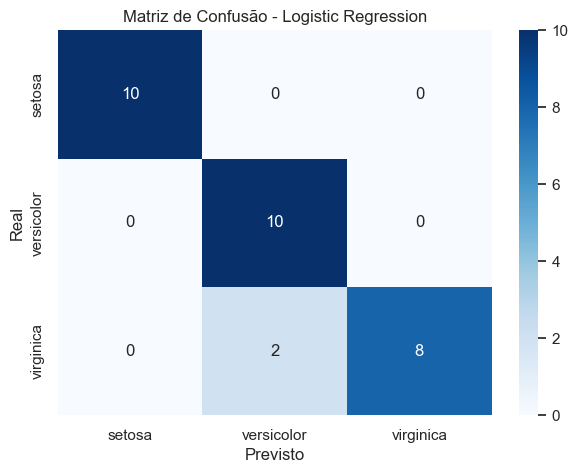

In [21]:
cm = confusion_matrix(y_test, pred)

plt.figure(figsize=(7, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=target_names,
    yticklabels=target_names
)

plt.title(f"Matriz de Confusão - {melhor_modelo_nome}")
plt.xlabel("Previsto")
plt.ylabel("Real")
plt.show()

# 17. PCA para visualização

O PCA reduz as quatro variáveis para duas componentes principais.

Aqui ele não é usado para treinar o modelo.  
Ele serve apenas para visualizar melhor a separação entre as espécies em um gráfico 2D.

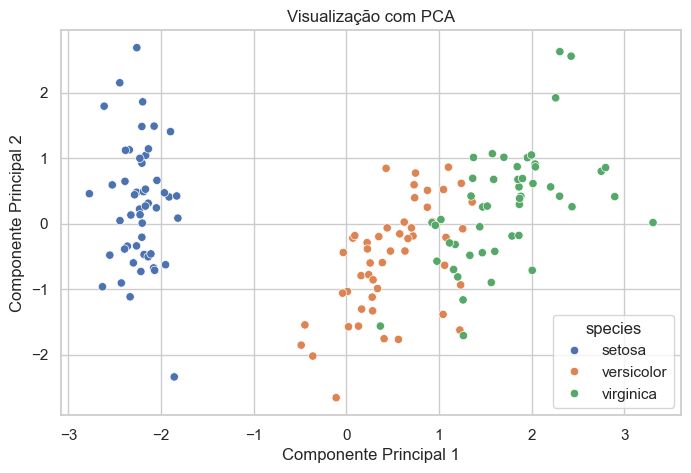

Variância explicada: [0.72962445 0.22850762]


In [22]:
scaler_pca = StandardScaler()
X_scaled = scaler_pca.fit_transform(X)

pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled)

df_pca = pd.DataFrame(X_pca, columns=["PC1", "PC2"])
df_pca["species"] = df["species"]

plt.figure(figsize=(8, 5))
sns.scatterplot(data=df_pca, x="PC1", y="PC2", hue="species")
plt.title("Visualização com PCA")
plt.xlabel("Componente Principal 1")
plt.ylabel("Componente Principal 2")
plt.show()

print("Variância explicada:", pca.explained_variance_ratio_)

# 18. Feature importance do Random Forest

Mesmo que o modelo final escolhido não seja o Random Forest, ele pode ser usado para interpretar a importância das variáveis.

Essa análise ajuda a entender quais medidas mais contribuem para separar as espécies.

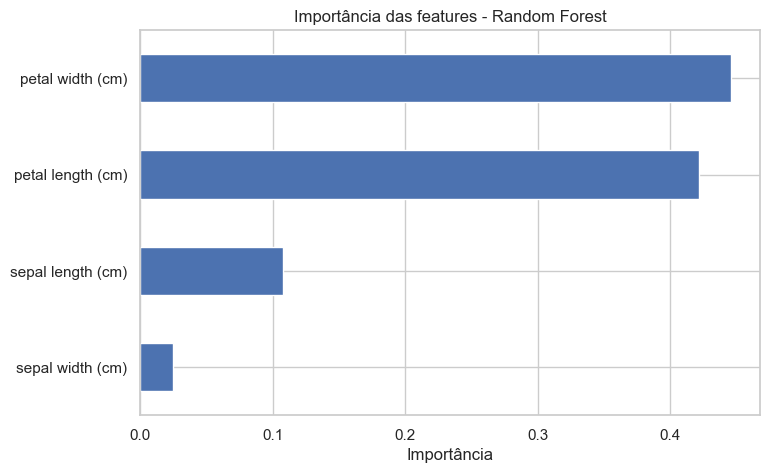

petal width (cm)     0.445725
petal length (cm)    0.421975
sepal length (cm)    0.107993
sepal width (cm)     0.024307
dtype: float64

In [23]:
rf_importance = RandomForestClassifier(
    n_estimators=200,
    random_state=RANDOM_STATE
)

rf_importance.fit(X_train_val, y_train_val)

serie_importancia = pd.Series(
    rf_importance.feature_importances_,
    index=features
).sort_values()

plt.figure(figsize=(8, 5))
serie_importancia.plot(kind="barh")
plt.title("Importância das features - Random Forest")
plt.xlabel("Importância")
plt.show()

serie_importancia.sort_values(ascending=False)

# 19. Salvamento do modelo final

Agora salvamos o modelo final em formato `.joblib`.

Esse arquivo será usado na aplicação Streamlit.  
Como o modelo foi salvo completo, ele mantém o Pipeline com normalização quando o modelo escolhido precisar dela.

In [24]:

os.makedirs("model", exist_ok=True)

# Salvar em joblib
joblib.dump(melhor_modelo, "model/modelo_final.joblib")

# Salvar também em pkl
with open("model/modelo_final.pkl", "wb") as arquivo:
    pickle.dump(melhor_modelo, arquivo)

# Salvar os nomes das classes
joblib.dump(list(target_names), "model/target_names.joblib")

print("Modelo salvo em: model/modelo_final.joblib")
print("Modelo salvo em: model/modelo_final.pkl")
print("Nomes das classes salvos em: model/target_names.joblib")

Modelo salvo em: model/modelo_final.joblib
Modelo salvo em: model/modelo_final.pkl
Nomes das classes salvos em: model/target_names.joblib


# 20. Teste do modelo salvo

Nesta etapa, carregamos o modelo salvo e fazemos uma previsão simples.

Isso confirma que o arquivo está funcionando e poderá ser usado no app Streamlit.

In [25]:
modelo_carregado = joblib.load("model/modelo_final.joblib")
classes_carregadas = joblib.load("model/target_names.joblib")

exemplo = pd.DataFrame([{
    "sepal length (cm)": 5.1,
    "sepal width (cm)": 3.5,
    "petal length (cm)": 1.4,
    "petal width (cm)": 0.2
}])

pred_exemplo = modelo_carregado.predict(exemplo)
classe_prevista = classes_carregadas[pred_exemplo[0]]

display(exemplo)
print("Espécie prevista:", classe_prevista)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2


Espécie prevista: setosa


# 21. Conclusão

Nesta versão da P2, o notebook foi reestruturado mantendo a base da P1, mas com melhorias na organização e na explicação.

Foram realizados:

- carregamento do dataset Iris pelo `scikit-learn`;
- análise exploratória dos dados;
- divisão estratificada em treino, validação e teste;
- normalização com Pipeline;
- comparação de três modelos;
- validação cruzada com StratifiedKFold;
- escolha do modelo final baseada no F1 Score Macro;
- avaliação no conjunto de teste;
- matriz de confusão;
- PCA para visualização;
- feature importance com Random Forest;
- salvamento do modelo final para uso no Streamlit.

O relatório e o app devem usar o mesmo modelo final escolhido neste notebook, para evitar divergência entre as entregas.